In [78]:
import pandas as pd
import numpy as np
import os
import urllib.request
import matplotlib.pyplot as plt
import seaborn as sns

In [79]:
#check folder status

os.makedirs('../data/raw', exist_ok = True)
os.makedirs('../data/processed', exist_ok = True)
os.makedirs('../reports', exist_ok = True)


In [80]:
print("We are the good to go")

We are the good to go


In [81]:
df = pd.read_csv("data/raw/Telco-Customer-Churn.csv")

In [82]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [83]:
print("Dataset Shape")
print(f"Rows : {df.shape[0]}")
print(f"Column : {df.shape[1]}")

Dataset Shape
Rows : 7043
Column : 21


In [84]:
print("Column names and Types")
print(df.dtypes)

Column names and Types
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [85]:
print("Row upto 5 lane")
print(df.head())

Row upto 5 lane
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies     

In [86]:
print("Data Quality")

print("Missing value per column")

missing = df.isna().sum()
print(missing[missing>0])
if missing.sum() == 0:
    print("No missing value")

#print("Duplicate Values")
#dupl = df.duplicated().sum()
#print("dupl")

print(f"Duplicate rows {df.duplicated().sum()}")
    
#rint("Checking customer ID ")
#cust_id = df.nunique()
#print("cust_id")

print(f"Customer IDs{df['customerID'].nunique()}")
print(f"Total rows: {len(df)}")
if df['customerID'].nunique() == len(df):
    print("All IDs exclusiveness verified")


Data Quality
Missing value per column
Series([], dtype: int64)
No missing value
Duplicate rows 0
Customer IDs7043
Total rows: 7043
All IDs exclusiveness verified


In [87]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [88]:
df.columns.tolist()


['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [89]:
print("Checking random sample")
df.sample(20, random_state = 99)

Checking random sample


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2905,4692-NNQRU,Female,0,Yes,No,21,Yes,No,Fiber optic,No,...,Yes,Yes,No,No,One year,No,Electronic check,79.20,1742.45,No
6651,2038-YSEZE,Female,0,No,No,29,Yes,Yes,DSL,Yes,...,No,Yes,No,No,Month-to-month,No,Mailed check,67.45,1801.1,No
5321,7718-UPSKJ,Female,0,Yes,No,69,Yes,No,Fiber optic,Yes,...,No,Yes,Yes,Yes,One year,Yes,Credit card (automatic),106.40,7251.9,No
4293,2114-MGINA,Female,0,No,No,14,Yes,No,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Mailed check,89.80,1129.1,Yes
5686,4369-HTUIF,Male,1,No,No,6,Yes,No,Fiber optic,Yes,...,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),85.15,503.6,Yes
2665,8166-ORCHU,Male,1,Yes,No,33,Yes,No,Fiber optic,Yes,...,No,Yes,No,Yes,One year,Yes,Electronic check,93.55,3055.5,No
457,0942-KOWSM,Female,0,Yes,Yes,30,Yes,No,DSL,No,...,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),80.80,2369.3,No
1106,4159-NAAIX,Female,0,No,No,63,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Two year,No,Bank transfer (automatic),97.45,6253,No
4945,1223-UNPKS,Male,0,Yes,Yes,20,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.05,400,No
7037,2569-WGERO,Female,0,No,No,72,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No


In [90]:
df.describe(include = "object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [91]:
df.isnull().sum().sort_values(ascending = False)

customerID          0
DeviceProtection    0
TotalCharges        0
MonthlyCharges      0
PaymentMethod       0
PaperlessBilling    0
Contract            0
StreamingMovies     0
StreamingTV         0
TechSupport         0
OnlineBackup        0
gender              0
OnlineSecurity      0
InternetService     0
MultipleLines       0
PhoneService        0
tenure              0
Dependents          0
Partner             0
SeniorCitizen       0
Churn               0
dtype: int64

In [92]:
miss_percent = (df.isnull().sum()/len(df))*100

miss_percent.sort_values(ascending = False)

customerID          0.0
DeviceProtection    0.0
TotalCharges        0.0
MonthlyCharges      0.0
PaymentMethod       0.0
PaperlessBilling    0.0
Contract            0.0
StreamingMovies     0.0
StreamingTV         0.0
TechSupport         0.0
OnlineBackup        0.0
gender              0.0
OnlineSecurity      0.0
InternetService     0.0
MultipleLines       0.0
PhoneService        0.0
tenure              0.0
Dependents          0.0
Partner             0.0
SeniorCitizen       0.0
Churn               0.0
dtype: float64

In [93]:
df["customerID"].duplicated().sum()

np.int64(0)

In [94]:
print("Target Variable (CHURN) ")

df["Churn"].value_counts()

Target Variable (CHURN) 


Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [95]:
df["Churn"].value_counts(normalize = True)*100


Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [96]:

print("Hence dataset is imbalance becuase it is not 50-50 set, it is aligned towards NO, which have to be considered at the time of model evaluation")

Hence dataset is imbalance becuase it is not 50-50 set, it is aligned towards NO, which have to be considered at the time of model evaluation


In [97]:
df.describe().round(3)

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000,7043.000,7043.000
mean,0.162,32.371,64.762
std,0.369,24.559,30.090
min,0.000,0.000,18.250
25%,0.000,9.000,35.500
50%,0.000,29.000,70.350
75%,0.000,55.000,89.850
max,1.000,72.000,118.750


In [98]:
print(f"Data type: {df["TotalCharges"].dtype }")

Data type: object


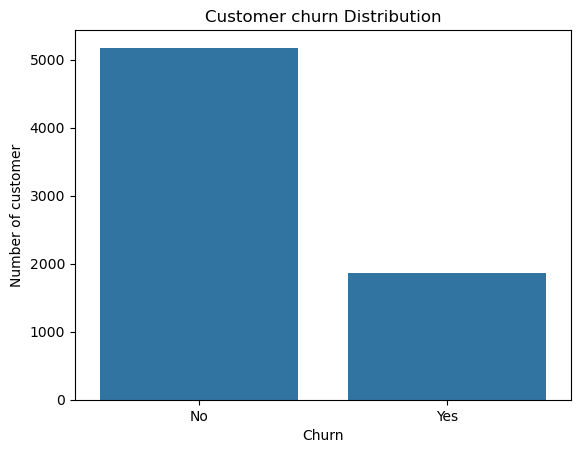

In [99]:
sns.countplot(data = df, x = "Churn")

plt.title("Customer churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of customer")
plt.show()

In [100]:
df.select_dtypes(include = np.number).columns.tolist()

['SeniorCitizen', 'tenure', 'MonthlyCharges']

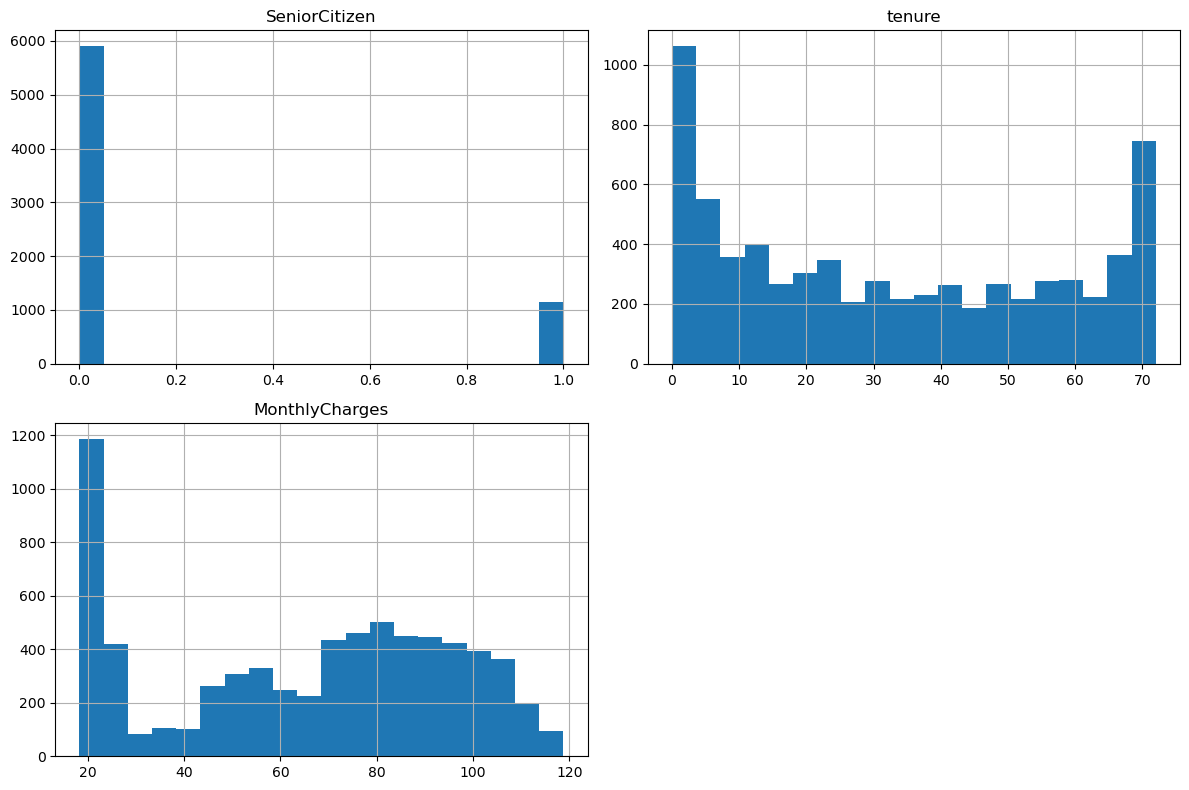

In [101]:
df.select_dtypes(include=np.number).hist(figsize = (12,8), bins = 20)
plt.tight_layout()
plt.show()

In [102]:
pd.crosstab(df["gender"], df["Churn"] )

Churn,No,Yes
gender,,
Female,2549,939
Male,2625,930


In [103]:
pd.crosstab(df["gender"], df["Churn"], normalize = "index")*100

Churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


In [104]:
pd.crosstab(df["Contract"], df["Churn"], normalize = "index") *100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [105]:
pd.crosstab(df["InternetService"], df["Churn"], normalize = "index") *100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [106]:
pd.crosstab(df["PaymentMethod"], df["Churn"], normalize = "index") *100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [107]:
df.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


In [108]:
df.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


In [109]:
df.groupby("Churn")["TotalCharges"].describe()

,count,unique,top,freq
Churn,,,,
No,5174,4966,,11
Yes,1869,1732,20.2,6


In [110]:
data_card = """
#Dataset : IBM Telco Customer Churn
source: https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv
Download date: 5 OCT 2026
Lincense : IBM sample data (no license file found)

#Data Overview
Rows : 7043, Columns : 21
Telecommunications provider (fictional data)

#Target Variable
'CHURN'
Class balance : 26.5% churned and 73.5 active 

#Key features
senior citizen, partner, internet service, online security, tech support, monthly charges, total charges, contract type, payment method and tenure

#Drawbacks
one snapshot in time , no temporal trends
fictional company 
No cost data
Churn reason not provided 
No customer feedback or satisfaction

#Use Case:
Build a reusable churn prediction pipeline that can work on similar dataset from different industries.
"""

with open ("C:/Users/slmkc/Downloads/PhaseI/Churn_model/reports/DATASET_Card.md","w") as f:
    f.write(data_card)

print(data_card)


#Dataset : IBM Telco Customer Churn
source: https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv
Download date: 5 OCT 2026
Lincense : IBM sample data (no license file found)

#Data Overview
Rows : 7043, Columns : 21
Telecommunications provider (fictional data)

#Target Variable
'CHURN'
Class balance : 26.5% churned and 73.5 active 

#Key features
senior citizen, partner, internet service, online security, tech support, monthly charges, total charges, contract type, payment method and tenure

#Drawbacks
one snapshot in time , no temporal trends
fictional company 
No cost data
Churn reason not provided 
No customer feedback or satisfaction

#Use Case:
Build a reusable churn prediction pipeline that can work on similar dataset from different industries.



In [111]:
df_raw = pd.read_csv("data/raw/Telco-Customer-Churn.csv")
df = df_raw.copy() #copy a file so that we preserve our raw file.
change_log = []


In [112]:
print(df.shape)

(7043, 21)


In [113]:
df.isnull().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [114]:
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": df.isnull().mean() * 100
})

missing = missing[missing["missing_count"] > 0]

missing.sort_values("missing_percent", ascending = False)

,missing_count,missing_percent


In [115]:
df["TotalCharges"].dtype

dtype('O')

In [116]:
df["TotalCharges"].head(20)

0       29.85
1      1889.5
2      108.15
3     1840.75
4      151.65
5       820.5
6      1949.4
7       301.9
8     3046.05
9     3487.95
10     587.45
11      326.8
12     5681.1
13     5036.3
14    2686.05
15    7895.15
16    1022.95
17    7382.25
18     528.35
19     1862.9
Name: TotalCharges, dtype: object

In [117]:
df["TotalCharges"].str.strip().value_counts().head()

TotalCharges
         11
20.2     11
19.75     9
20.05     8
19.9      8
Name: count, dtype: int64

In [118]:
blank = df["TotalCharges"].astype(str).str.strip() == ""
print(blank)
print(blank.sum())

0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Name: TotalCharges, Length: 7043, dtype: bool
11


In [119]:
pd.to_numeric(df["TotalCharges"], errors = "coerce").isna().sum()

np.int64(11)

In [120]:
df.duplicated().sum()

np.int64(0)

In [121]:
duplicates = df[df.duplicated(keep = False)]

duplicates

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [122]:
df["customerID"].duplicated().sum()

np.int64(0)

In [123]:
blank = df["TotalCharges"].astype(str).str.strip() == ""
print("Blank TotalCharges: ",blank.sum())
print(df.loc[blank, ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]])

Blank TotalCharges:  11
      customerID  tenure  MonthlyCharges TotalCharges Churn
488   4472-LVYGI       0           52.55                 No
753   3115-CZMZD       0           20.25                 No
936   5709-LVOEQ       0           80.85                 No
1082  4367-NUYAO       0           25.75                 No
1340  1371-DWPAZ       0           56.05                 No
3331  7644-OMVMY       0           19.85                 No
3826  3213-VVOLG       0           25.35                 No
4380  2520-SGTTA       0           20.00                 No
5218  2923-ARZLG       0           19.70                 No
6670  4075-WKNIU       0           73.35                 No
6754  2775-SEFEE       0           61.90                 No


In [124]:
df["customerID"].isna().sum()

np.int64(0)

In [125]:
df["customerID"].nunique()

7043

In [126]:
len(df)

7043

In [127]:
broken = pd.to_numeric(df["TotalCharges"], errors = "coerce").isnull()
print("Values that are not numbers: ", broken.sum())

Values that are not numbers:  11


In [128]:
df[broken][["customerID","tenure","MonthlyCharges","TotalCharges","Churn"]]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [129]:
print("Rows", len(df))
print("Unique customer id", df["customerID"].nunique())

Rows 7043
Unique customer id 7043


In [130]:
print("Duplicate rows", df.duplicated().sum())
print("Duplicate customer ids", df["customerID"].duplicated().sum())

Duplicate rows 0
Duplicate customer ids 0


In [131]:
cat_cols = ["gender", "Partner", "Dependents", "PhoneService", "MultipleLines",
            "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
            "TechSupport", "StreamingTV", "StreamingMovies", "Contract",
            "PaperlessBilling", "PaymentMethod", "Churn"]

for col in cat_cols:
    print(col, "--", list(df[col].unique()))

gender -- ['Female', 'Male']
Partner -- ['Yes', 'No']
Dependents -- ['No', 'Yes']
PhoneService -- ['No', 'Yes']
MultipleLines -- ['No phone service', 'No', 'Yes']
InternetService -- ['DSL', 'Fiber optic', 'No']
OnlineSecurity -- ['No', 'Yes', 'No internet service']
OnlineBackup -- ['Yes', 'No', 'No internet service']
DeviceProtection -- ['No', 'Yes', 'No internet service']
TechSupport -- ['No', 'Yes', 'No internet service']
StreamingTV -- ['No', 'Yes', 'No internet service']
StreamingMovies -- ['No', 'Yes', 'No internet service']
Contract -- ['Month-to-month', 'One year', 'Two year']
PaperlessBilling -- ['Yes', 'No']
PaymentMethod -- ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']
Churn -- ['No', 'Yes']


In [132]:
pd.crosstab(df["InternetService"], df["OnlineSecurity"])

OnlineSecurity,No,No internet service,Yes
InternetService,,,
DSL,1241,0,1180
Fiber optic,2257,0,839
No,0,1526,0


In [133]:
pd.crosstab(df["PhoneService"], df["MultipleLines"])

MultipleLines,No,No phone service,Yes
PhoneService,,,
No,0,682,0
Yes,3390,0,2971


In [134]:
df[["SeniorCitizen", "tenure", "MonthlyCharges"]].describe().round(2)

,SeniorCitizen,tenure,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75


In [135]:
print(df["Churn"].value_counts())
print((df["Churn"].value_counts(normalize = True)*100).round(2))

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [136]:
df_clean = df.copy()

In [137]:
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors = "coerce")
df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(0)

print("Type now: ", df_clean["TotalCharges"].dtype)
print("Missing now", df_clean["TotalCharges"].isnull().sum())

Type now:  float64
Missing now 0


In [138]:
df_clean["Churn"] = df_clean["Churn"].map({"No": 0, "Yes":1})
df_clean["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [139]:
yes_no_cols = ["Partner", "Dependents", "PhoneService", "MultipleLines", "PaperlessBilling",
               "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
               "StreamingTV", "StreamingMovies"]

for col in yes_no_cols:
    df_clean[col] = df_clean[col].astype(str).str.strip()
    df_clean[col] = df_clean[col].map({"Yes": 1 , "No": 0, "No internet service": 0, "No phone Service": 0})
    df_clean[col] = df_clean[col].fillna(0)

print("Nan Values Left: ", df_clean[yes_no_cols].isnull().sum().sum())
   

Nan Values Left:  0


In [140]:
print("Row and Column", df_clean.shape)
print("Missing values", df_clean.isnull().sum().sum())
print("Duplicate row", df_clean.duplicated().sum())
print("Duplicate Customer ID", df_clean["customerID"].duplicated().sum())
print("TotalCharges type", df_clean["TotalCharges"].dtype)
print("Churn value", df_clean["Churn"].unique())
print("Smallest tenure", df_clean["tenure"].min())
print("Smallest Monthly Charges", df_clean["MonthlyCharges"].min())
print("Churn rate" , round(df_clean["Churn"].mean(),4))

Row and Column (7043, 21)
Missing values 0
Duplicate row 0
Duplicate Customer ID 0
TotalCharges type float64
Churn value [0 1]
Smallest tenure 0
Smallest Monthly Charges 18.25
Churn rate 0.2654


In [141]:
print(df_clean.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [142]:
df_clean[["Partner", "OnlineSecurity", "TechSupport"]].head(10)

,Partner,OnlineSecurity,TechSupport
0,1,0,0
1,0,1,0
2,0,1,0
3,0,1,1
4,0,0,0
5,0,0,0
6,0,0,0
7,0,1,0
8,1,0,1
9,0,1,0


In [143]:
print("MultipleLines uqique Values")
print(df_clean["MultipleLines"].unique())


MultipleLines uqique Values
[0. 1.]


In [144]:
print("OnlineSecurity unique values")
print(df_clean["OnlineSecurity"].unique())

OnlineSecurity unique values
[0 1]


In [145]:
def table(data):
    table = pd.DataFrame({
        "type": data.dtypes,
        "missing": data.isnull().sum(),
        "unique_values": data.nunique(),
    })
    return table

In [146]:
table(df).loc[["TotalCharges", "Churn", "Partner"]]

,type,missing,unique_values
TotalCharges,object,0,6531
Churn,object,0,2
Partner,object,0,2


In [147]:
table(df_clean).loc[["TotalCharges", "Churn", "Partner"]]

,type,missing,unique_values
TotalCharges,float64,0,6531
Churn,int64,0,2
Partner,int64,0,2


In [148]:
print("Partner unique values")
print(df_clean["Partner"].unique())


Partner unique values
[1 0]


In [149]:
print("Partner Value counts")
print(df_clean["Partner"].value_counts())

Partner Value counts
Partner
0    3641
1    3402
Name: count, dtype: int64


In [150]:
df[["Partner"]].head(10)

,Partner
0,Yes
1,No
2,No
3,No
4,No
5,No
6,No
7,No
8,Yes
9,No


In [151]:
print("Raw partner values, with quotes to see spaces")

for val in df["Partner"].unique():
    print(f"'{val}'")

Raw partner values, with quotes to see spaces
'Yes'
'No'


In [152]:
print("Row and column", df_clean.shape)
print("Missing values", df_clean.isnull().sum().sum())
print("Duplicate row", df_clean.duplicated().sum())
print("Duplicate Customer ID", df_clean["customerID"].duplicated().sum())
print("Total Charges Type", df_clean["TotalCharges"].dtype)
print("Churn Value", df_clean["Churn"].unique())
print("Smallest tenure", df_clean["tenure"].min())
print("Smallest Monthly Charges", df_clean["MonthlyCharges"].min())
print("Churn rate", round(df_clean["Churn"].mean(), 4))

Row and column (7043, 21)
Missing values 0
Duplicate row 0
Duplicate Customer ID 0
Total Charges Type float64
Churn Value [0 1]
Smallest tenure 0
Smallest Monthly Charges 18.25
Churn rate 0.2654


In [153]:
df_clean.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,1,0,1,0,0.0,DSL,0,...,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,0,0,34,1,0.0,DSL,1,...,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,0,0,2,1,0.0,DSL,1,...,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,0,0,45,0,0.0,DSL,1,...,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,0,0,2,1,0.0,Fiber optic,0,...,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


In [154]:
df_clean.to_csv("C:/Users/slmkc/Downloads/PhaseI/Churn_model/data/processed/telco_clean.csv", index = False)


In [155]:
pd.read_csv("C:/Users/slmkc/Downloads/PhaseI/Churn_model/data/processed/telco_clean.csv").shape

(7043, 21)

In [156]:
cleaning_log = """
#cleaning log - IBM Telco Customer Churn

Total charges: Converted from text to number
Total Charges: 11 Blank values
Churn: No/Yes converted to 0/1
No internet service / No phone servie counted as No in 7 col, becuase InternetService and PhoneService already store this information
Yes/No columns converted to 1/0

Everything has been fixed
"""
with open("C:/Users/slmkc/Downloads/PhaseI/Churn_model/reports/cleaning_log.md", "w") as f:
    f.write(cleaning_log)

print("Saved")

Saved
